# Time Series Analysis: Missing Values

Time Series data often stems from real world sensors. Those sensors are vulnerable to electrical, physical and other influences that can cause missing values in the recorded data.

However, most time series analysis algorithms demand complete data. One could either exclude the missing value blocks entirely - creating incomplete analyses - or impute the missing values. To make algorithms be as accurate as possible, those imputations should be as close as possible to the data that went missing. 

One can use heuristics, the data itself or related data to try to guess the missing data points. We present some of those algorithms in this lecture.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import meteostat as ms
from datetime import datetime

Let's import some weather data around Bolzano

In [2]:
bolzano = ms.Point(46.5, 11.35, 262)  

# Get nearby weather stations
stations = ms.stations.nearby(bolzano, limit=10, radius=1000000)
station_ids = stations.index.tolist()

# Define time range
start = datetime(2023, 1, 1)
end = datetime(2023, 2, 28)

ms.config.block_large_requests = False
data = ms.hourly(station=station_ids, start=start, end=end, parameters=["temp"])

# Fetch data
ts_data = data.fetch().reset_index().pivot(index='time', columns='station', values='temp').squeeze()
ts_data_raw = ts_data.values.astype(np.float64)

# Fetch locational data for ST-MVL
valid_station_ids = ts_data.columns.unique()
filtered_stations = stations.loc[valid_station_ids]
locations = filtered_stations[['latitude', 'longitude']].values

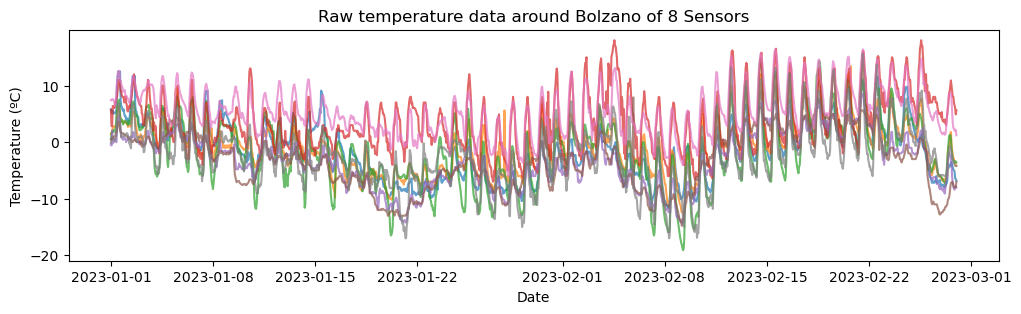

In [3]:
plt.figure(figsize=(12, 3))
plt.title(f"Raw temperature data around Bolzano of {len(ts_data.columns)} Sensors")
plt.ylabel("Temperature (ºC)")
plt.xlabel("Date")
plt.plot(ts_data, alpha=0.7)
plt.show()

Let's create a missing data block

In [4]:
X_incomplete = ts_data_raw.copy().astype(np.float64)
n_time_points, n_time_series = X_incomplete.shape
np.random.seed(42)

target_sensor = 0 # Define first sensor for simplicity
hole_length = np.random.randint(low = n_time_points // 20, high = n_time_points // 4)

minimum_history = n_time_points // 3
hole_start = np.random.randint(low = minimum_history, high = n_time_points - hole_length)
hole_end = hole_start + hole_length
X_incomplete[hole_start:hole_end, target_sensor] = np.nan # Fill missing values with NaNs

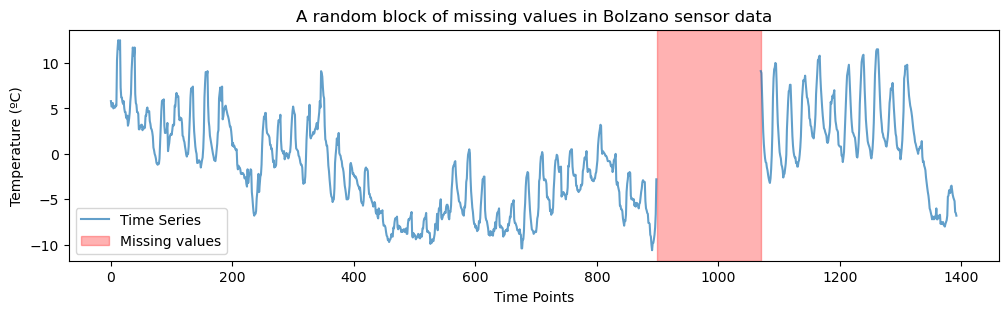

In [5]:
plt.figure(figsize=(12, 3))
plt.title("A random block of missing values in Bolzano sensor data")
plt.plot(X_incomplete[:, 0], alpha=0.7, label='Time Series')
plt.axvspan(hole_start, hole_end, alpha=0.3, color='red', label='Missing values')
plt.xlabel("Time Points")
plt.ylabel("Temperature (ºC)")
plt.legend()
plt.show()

## 1. Basics: Interpolation
One of the simplest methods for imputing data is interpolation of the same dataset, i.e. not using related datasets for "inspiration". There are plenty of approaches to interpolation, ranging from constant over linear interpolation between the edges of the missing block up to e.g. spline interpolation which uses a set of polynomials. 

Pandas offers a simple function to interpolate data:

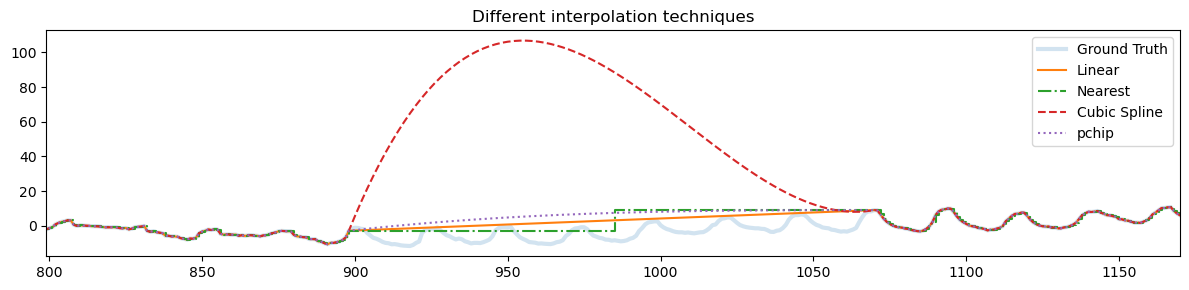

In [6]:
df_incomplete = pd.DataFrame(X_incomplete[:, target_sensor])

linear_interpolation = df_incomplete.interpolate(method="linear")
nearest_interpolation = df_incomplete.interpolate(method="nearest")
pchip_interpolation = df_incomplete.interpolate(method="pchip")
qspline_interpolation = df_incomplete.interpolate(method="cubicspline")

plt.figure(figsize=(12, 3))
plt.title("Different interpolation techniques")
plt.plot(ts_data_raw[:, 0], lw=3, alpha=0.2, label="Ground Truth")
plt.plot(linear_interpolation, label="Linear", linestyle="-")
plt.plot(nearest_interpolation, label="Nearest", linestyle="-.", drawstyle='steps-post')
plt.plot(qspline_interpolation, label="Cubic Spline", linestyle="--")
plt.plot(pchip_interpolation, label="pchip", linestyle=":")
plt.xlim((hole_start-100, hole_end+100))
plt.legend()
plt.tight_layout()
plt.show()

As one can see, cubic splines are not suited for the imputation of bigger blocks (though they are a popular choice for point interpolation). A higher-order polynomial such as Cubic-Spline tries to match both edge values as well as first and second order derivatives across the gap. With a growing gap size, this can lead to overshooting. <br> The other imputation methods perform better on the missing data block, but still lack detail.

To utilize periodicity of the data, other algorithms we have seen before can be used, e.g. ARIMA, DFT etc. Especially for seasonal data, imputing the missing data with data from the last season can be sufficient.

However, if data from related sensors is available, one can try to utilize it to impute the missing values in the current sensor more accurately. The algorithms shown in the lecture all build on this principle.

## 2. CDRec

With CDRec we are entering a complex space of ideas where each solves a bottleneck of the previous. Breaking them down, it is
1. Finding hidden patterns and their importance with the matrix decomposition **SVD**

2. Reducing the computational complexity of SVD through **CD** by approximation

3. Reducing the memory complexity of CD via **SSV** by processing the data in a specific order

The recovery of missing data fundamentally relies on SVD to find the **hidden patterns** needed to impute the data. CD and SSV are following the same goal and are only used for more **efficient** calculations.

A sidenote on sets of time series: As they can be written as a matrix, one can understand them as a linear transformation. It transforms from the *sensor* space to the *time* space (when sensors are columns). <br> Multiplying it by a vector in sensor space basically gives an averaged time series from weighted sensors. Similarly, multiplying a vector in time space with the transposed matrix gives an average value for each sensor weighted over time.

### 2.1. SVD
Singular Value Decomposition (SVD) is in its core a way to mathematically describe any matrix as a **composition** of 3 matrices that have some nice properties. 

Meaning however complex a given linear transformation given by a matrix is, it can be split into a **rotation** followed by a **scaling** followed by another rotation. The rotational actions and the amount of scaling can be analyzed to find hidden patterns (the **latent factors**) within the data.

As a lot of data can be described with matrices, SVD has a lot of different use cases:
- In **recommender systems**, items and users can span a matrix where the values are e.g. ratings. SVD reveals hidden clusters (e.g., users who share a similar taste for emotional movies) both for users and movies.

- **A set of time series** spans a matrix with time points and sensors at the axis where the values are the measurements. SVD finds the dominant underlying behaviours (e.g., a shared daily temparature cycle) while discarding noisy anomalies.

- **Pictures** can be understood as pixel matrices. SVD allows compression by isolating the most important structural features from barely visible background static.

- **Principal Component Analysis** (PCA), which finds the most important dimensions or axes of variance in data, is directly calculated using SVD.

- **Geometrically**, any matrix can be written as a sequence of three physical movements: a rotation in the input space, a stretching/scaling along the axes, and another rotation into the output space. There are even more abstract mathematical interpretations.

------

Formally, SVD states that a matrix $A = U\Sigma V^*$ can be decomposed into three parts:
- $U$ row wise latent (hidden) factors (e.g. for users, time points)

- $\Sigma$ is a diagonal matrix of sorted **Singular Values**. These represent the importance (weight) of each latent factor.
    - Singular Values are related to Eigenvalues: Singular Values are the square root of the eigenvalues of $MM^T$ or $M^TM$. Eigenvalues only exist for square matrices, while Singular Values can exist for any matrix shape.

- $V^*$ column wise latent (hidden) factors (e.g. for songs, time series sensors)
    - $V^*$ is the conjugate transpose (transposing and flipping complex part sign). For real numbers it holds that $V^* = V^T$ is the normal transpose.

Geometrically, the first of these latent factors defines the longest **axis** running perfectly through the center of the multidimensional data cloud (e.g., understanding a time series as a point in high-dimensional space). This single line captures the absolute maximum amount of **variance** in the dataset. The Singular Value of that latent factor is proportional to the variance captured with that one line. Each subsequent factor finds the next perpendicular (statistically unrelated) line that captures the most remaining variance.

By forcing $U$ and $V^*$ to a **smaller rank** $k$ than the original matrix, it becomes an **approximation**. Because the math prioritizes being as close to the original matrix as possible, only the strongest, most important hidden patterns survive this compression. In fact, it is the best approximation possible with $k$ ranks. By decompressing these dominant patterns, the missing values are naturally reconstructed.

There are several algorithms to calculate the SVD, e.g. `np.linalg.svd`. However, SVD's runtime is $\mathcal{O}(mn^2)$ for a matrix of shape $m\times n$, $m\ge n$. This becomes infeasable very fast, especially for growing time series.

----

A lot of explanations of SVD are very mathematically dense and can be found plentyful. Here are some example resources that try to teach a more intuitive approach:
-  Focus on the linear algebra view of storing data in tables / matrices [Part I](https://www.jeremykun.com/2016/04/18/singular-value-decomposition-part-1-perspectives-on-linear-algebra/) and a thoroughly explained mathematical background with a custom SVD implementation [Part II](https://www.jeremykun.com/2016/05/16/singular-value-decomposition-part-2-theorem-proof-algorithm/).

- A playlist of around 1h that visually covers SVD and spectral decomposition can be found [here](https://www.youtube.com/playlist?list=PLWhu9osGd2dB9uMG5gKBARmk73oHUUQZS).

- How to derive SVD from first principles can be found [here](https://markelic.de/deriving-the-singular-value-decomposition-svd-from-first-principles/).


### 2.2. CD
An approximation of SVD for dimensionality reduction is Centroid Decomposition (CD), which reduces the complexity to $\mathcal{O}(kn^2)$. Note that this means calculating all latent factors with CD is not less complex than SVD. <br> Instead of calculating the exact latent factors and singular values, CD calculates a loading matrix $L$ and a relevance matrix $R$ for a matrix $X$ such that
$$X \approx L \cdot R^T \approx (U\Sigma) \cdot V^T$$

To approximate the Singular Values which geometrically represent a perfect line through the data CD simply searches for a modified center of mass (the centroid). The distance of this newly formed centroid from the origin serves as a highly accurate proxy for the SVD's Singular Value (the weight or importance of the pattern), while the centroid's direction serves as the latent factor.

CD finds this centroid by introducing a sign vector consisting entirely of binary choices: $1$ and $-1$. The algorithm evaluates the data and deliberately "flips" the signs of specific rows. By flipping rows that point in opposing directions, the algorithm forces the data points to accumulate on one side of the space, pushing the center of mass as far from the origin as possible.

The important properties, i.e. latent factor and Singular Value equivalents, follow directly from the aquired sign vector and the data.

However, CD has a quadratic memory complexity. To figure out which rows to flip, it naively calculates the relationship between every single time point and every other time point, creating a $n \times n$ distance matrix.

----

The implementation below follows that logic. First, it creates two matrices $L$ and $R$ of rank $k$.

For each latent factor it fetches the sign vector. Then it computes the centroid vector from the sign vector and the data. The relevance vector is simply the normalized centroid vector. The loading vector is calculated from data and the relevance vector.

To have the next latent factor be independent of the current one, the result of the matrix gets subtracted from the data.

### 2.3. SSV
Scalable Sign Vector (SSV) takes over the memory heavy part of CD and scales well for data with way more data points than samples. Time series are thus a good fit, as usually one has less time series than the time series are long ($m \ll n$).

Instead of naively comparing every time point to every other time point pairwise to find the correct sign flipping in CD, SSV changes the order of operations. It compares each individual data point to a single, running "summary vector" of the samples. <br> By skipping the creation of a memory intensive $n \times n$ cross-comparison table, SSV pushes the memory requirement down to just $\mathcal{O}(n)$. 

---

The implementation for SSV first initializes a sign vector entirely of ones. Additionally, a weight vector $V$ is declared, which calculates how much each row interacts with the rest of the dataset (ignoring its self-correlation). Because a row's self-correlation ($X_{i*} \cdot X_{i*}^T$) remains completely static, we compute it just once upfront in `row_energies` to save processing time.

During the iterative loop, the algorithm scans for any row where flipping its sign would increase the total centroid value. If multiple beneficial flips exist, it greedily selects the one with the highest absolute weight. It recalculates the weights and repeats this process until no further sign flips can increase the centroid.

In [7]:
def scalable_sign_vector(input_matrix):
    n, m = input_matrix.shape
    
    # 1: Initialize sign vector
    sign_vector = np.ones(n)
    row_energies = np.sum(input_matrix**2, axis=1)

    pos = -1 
    while True:
        # 2: Change Sign of position
        if pos != -1:
            sign_vector[pos] *= -1

        # 3: Determine weight vector
        intermediate_vector = input_matrix.T @ sign_vector
        weight_vector = sign_vector * (sign_vector * (input_matrix @ intermediate_vector) - row_energies)

        # 4: Search next element
        condition = (sign_vector * weight_vector) < 0
        
        if not np.any(condition):
            break # No valid sign changes left, terminate
            
        # 5: Get the index of the maximum absolute weight
        valid_weights = np.where(condition, np.abs(weight_vector), -1.0)
        pos = np.argmax(valid_weights)
            
    return sign_vector

def centroid_decomposition(input_matrix, k=None):
    n, m = input_matrix.shape

    if k is None:
        k = m

    # 1: Initialize decomposition matrices (L and R)
    loading_matrix = np.zeros((n, k))
    relevance_matrix = np.zeros((m, k))

    # Iteratively extract 'k' components
    for i in range(k):
        # 2: Find the optimal sign vector that maximizes the centroid norm
        max_sign_vector = scalable_sign_vector(input_matrix)
        
        # 3: Compute the centroid vector (direction of maximum variance)
        centroid_vector = input_matrix.T @ max_sign_vector

        # 4: Compute the normalized relevance vector (column weights / Right matrix)
        r_vector = centroid_vector / np.linalg.norm(centroid_vector)
        relevance_matrix[:, i] = r_vector

        # 5: Compute the loading vector (row weights / Left matrix)
        l_vector = input_matrix @ r_vector
        loading_matrix[:, i] = l_vector

        # 6: Deflate the matrix by subtracting the extracted rank-1 component
        input_matrix = input_matrix - np.outer(l_vector, r_vector)

    return loading_matrix, relevance_matrix

### 2.4. Recovery

The recovery process based on CD (CDRec) begins by caching the exact positions of the missing data points. Because matrix decomposition algorithms cannot process pure `NaN` values, it temporarily fills these holes using simple **linear interpolation** to provide a mathematical starting point.

Next, the algorithm enters an iterative loop. It continually **refines** these initial guesses until either a maximum number of iterations is reached, or the predictions stabilize (meaning they stop changing significantly between loops). This stabilization is measured using the Frobenius norm, which is essentially the Euclidean distance applied to entire matrices.

Inside this loop, the matrix is decomposed using Centroid Decomposition, but specifically restricted to a **lower rank** $k$. By forcing the algorithm to use fewer dimensions ($k$) than the original data, we strip away the noise and force it to capture only the most dominant, underlying patterns. The matrix is then mathematically **reconstructed** from these core patterns, and the `NaN` gaps are overwritten with the newly predicted, pattern-aligned values.

In [8]:
def cd_rec(input_matrix, k, epsilon=1e-3, max_iterations=100):
    # 1: Initialization
    # Find a mask of where the missing values are
    missing_mask = np.isnan(input_matrix)
    
    # Create a working copy of the matrix
    X_current = input_matrix.copy()
    
    # Initialize NaNs with the column mean (standard practice for iterative SVD/CD)
    X_current = pd.DataFrame(X_current).interpolate(method="linear", limit_direction="both").values.copy()

    # 2: Iterative Imputation Loop
    for _ in range(max_iterations):
        X_previous = X_current.copy()

        col_means_iter = np.mean(X_current, axis=0)
        X_centered = X_current - col_means_iter
        
        # 3: Perform CD with rank reduction (only compute 'k' vectors)
        L, R = centroid_decomposition(X_centered, k=k)
        
        # 4: Reconstruct the matrix using the reduced rank matrices
        X_reconstructed = L @ R.T +  col_means_iter
        
        # 5: Update ONLY the missing values in the current matrix
        X_current[missing_mask] = X_reconstructed[missing_mask]
        
        # 6: Convergence Check
        # Calculate the Frobenius norm of the difference
        frobenius_diff = np.linalg.norm(X_current - X_previous, ord='fro')
        
        if frobenius_diff < epsilon:
            break
            
    return X_current

The parameter $k$ has to be smaller than the number of reference time series to force an approximation - otherwise the refinement condition of stable approximations is met immediately despite no refinement happening yet. <br> Furthermore, a too small $k$ might miss important patterns while a too large $k$ can include too much noise in the prediction.

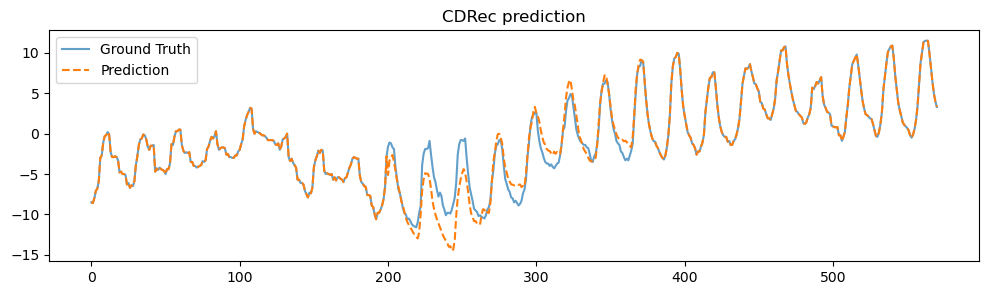

In [9]:
buffer_around_hole = 200
prediction_cdrec = cd_rec(X_incomplete[hole_start-buffer_around_hole:hole_end+buffer_around_hole, :], k=2)

plt.figure(figsize=(12, 3))
plt.title("CDRec prediction")
plt.plot(ts_data_raw[hole_start-buffer_around_hole:hole_end+buffer_around_hole, 0], alpha=0.7, label="Ground Truth")
plt.plot(prediction_cdrec[:, 0], label="Prediction", linestyle="--")
# plt.xlim((hole_start-100, hole_end+100))
plt.legend()
plt.show()

## 3. ST-MVL

In a sensor network, data is heavily influenced by both its location (spatial) and the passage of time (temporal). 

If a weather station goes offline, you can make a good guess about the missing temperature by asking four different questions: What was the temperature 10 minutes ago? What is the temperature at the station next door right now? What is the temperature usually like on this day of the year? What nearby sensor usually has the most similar values? ST-MVL formalizes this by combining four distinct **views** on the data.

----
We are presenting ST-MVL in the class shape of popular ML libraries like scikitlearn, meaning a split of the process into the functions **fit and transform**.

The algorithm takes a window size, a spatial decay rate (how fast we stop trusting further away sensors), a smoothing rate for temporal weights and a temporal threshold for excluding too old values as input entirely.

It combines four views on the data:
1. A **global spatial** view over all related sensors (e.g., "This station usally shares the same climate as the one in Merano.")

2. A **global temporal** view over its own data (e.g., "Historically, it is usally around 15ºC at this time.")
3. A **local spatial** view looks at the current readings of geographically nearby sensors (e.g., "The station in Trento reads 20ºC right now.")
4. A **local temporal** view looks at the immediate past and future of the broken sensor (e.g., "It was 10ºC a few minutes ago.")

`fit()` serves as the model's training phase. It processes a historical, complete dataset to compute the independent estimations generated by each of the four spatio-temporal views. These parallel estimations are subsequently used as features to train a multiple linear regression model. The paper states "minimizing the least square error". <br> The regression phase calculates the optimal weighting for each view, systematically quantifying the relative reliability and predictive power of each component for the specific dataset at hand.

`transform()` executes the actual data imputation. Upon encountering missing values in new data, it first computes the current estimations from each of the four views. It then applies the optimized weights learned during the `fit()` phase to linearly combine these individual estimations, yielding a single, robust final guess to replace the missing data point.

In [10]:
from sklearn.linear_model import LinearRegression
from scipy.spatial.distance import cdist

class ST_MVL:
    def __init__(self, window_size, decay_rate, smoothing_rate, temporal_threshold):
        # Viewing variables
        self.window_size = window_size
        self.decay_rate = decay_rate
        self.smoothing_rate = smoothing_rate       
        self.temporal_threshold = temporal_threshold 

        # Calculated from station positions
        self.sensor_distances_ = None

        # Multiview Learning parameters
        self.weigths_ = None
        self.intercepts_ = None
        self.is_fitted = False

    def _global_spatial_view_idw(self, target_time, target_sensor, input_matrix):
        # Filter out missing values and the target sensor itself (where distance is 0)
        dists = self.sensor_distances_[target_sensor]
        valid = ~np.isnan(input_matrix[target_time]) & (dists > 0)

        # Assign weight to candidate sensors readings based on geographic distance
        values = input_matrix[target_time, valid]
        spatial_weights = 1.0 / (dists[valid] ** self.decay_rate)

        if not np.any(valid): 
            return np.nan
        else:
            return np.average(values, weights=spatial_weights)

    def _global_temporal_view_ses(self, target_time, target_sensor, input_matrix):
        # Generate relative time steps and map to absolute matrix indices
        dt = np.arange(1, self.temporal_threshold + 1)
        context_times = np.concatenate([target_time - dt, target_time + dt])

        # Calculate theoretical exponential smoothing weights for each time step
        temporal_weights = np.concatenate([self.smoothing_rate * (1 - self.smoothing_rate)**(dt - 1)] * 2)

        # Filter out strictly out-of-bounds indices and missing values
        in_bounds = (context_times >= 0) & (context_times < input_matrix.shape[0])
        context_times, temporal_weights = context_times[in_bounds], temporal_weights[in_bounds]
        valid = ~np.isnan(input_matrix[context_times, target_sensor])

        # Assign weight to historical/future values based on temporal difference
        values = input_matrix[context_times[valid], target_sensor]
        temporal_weights = temporal_weights[valid]

        if not np.any(valid): 
            return np.nan
        else:
            return np.average(values, weights=temporal_weights)


    def _local_spatial_view_ucf(self, target_time, target_sensor, input_matrix, window_start, window_end):
        n_times, n_sensors = input_matrix.shape
        
        # The historical time sequence we want to match against
        target_sensor_trend = input_matrix[window_start:window_end, target_sensor]
        values, spatial_similarities = [], []

        # Find candidate sensors that have a similar recent trend to our target sensor
        for candidate_sensor in range(n_sensors):
            if candidate_sensor == target_sensor or np.isnan(input_matrix[target_time, candidate_sensor]):
                continue
            
            # Isolate the candidate's trend for the exact same time window
            candidate_sensor_trend = input_matrix[window_start:window_end, candidate_sensor]
            
            # Only compare timestamps where both sensors have valid readings
            valid = ~np.isnan(target_sensor_trend) & ~np.isnan(candidate_sensor_trend)

            if np.any(valid):
                # Calculate similarity between the two trends
                dist = np.sqrt(np.mean((target_sensor_trend[valid] - candidate_sensor_trend[valid]) ** 2))

                if dist > 0:
                    # Weight the candidate sensor's current reading by its trend similarity
                    values.append(input_matrix[target_time, candidate_sensor])
                    spatial_similarities.append(1.0 / dist)

        return np.average(values, weights=spatial_similarities) if spatial_similarities else np.nan


    def _local_temporal_view_icf(self, target_time, target_sensor, input_matrix, window_start, window_end):
        # The geographic snapshot of all sensors at the moment data went missing
        target_spatial_pattern = input_matrix[target_time, :]
        values, temporal_similarities = [], []

        # Find close timestamps that had a similar geographic snapshot
        for candidate_time in range(window_start, window_end):
            if candidate_time == target_time or np.isnan(input_matrix[candidate_time, target_sensor]):
                continue
            
            # Isolate the geographic snapshot for the candidate time
            candidate_spatial_pattern = input_matrix[candidate_time, :]
            
            # Only compare sensors that have values for both the target and candidate times
            valid = ~np.isnan(target_spatial_pattern) & ~np.isnan(candidate_spatial_pattern)

            if np.any(valid):
                # Calculate similarity of the two geographic snapshots
                dist = np.sqrt(np.mean((target_spatial_pattern[valid] - candidate_spatial_pattern[valid]) ** 2))

                if dist > 0:
                    # Weight the target sensor's reading by the spatial map similarity
                    values.append(input_matrix[candidate_time, target_sensor])
                    temporal_similarities.append(1.0 / dist)
        
        return np.average(values, weights=temporal_similarities) if temporal_similarities else np.nan
    
    def _get_all_views(self, time, sensor, input_matrix):
        # Calculate window boundaries for local views
        start = max(0, time - self.window_size // 2)
        end = min(input_matrix.shape[0], time + self.window_size // 2 + 1)

        return np.array([
            self._global_spatial_view_idw(time, sensor, input_matrix),
            self._global_temporal_view_ses(time, sensor, input_matrix),
            self._local_spatial_view_ucf(time, sensor, input_matrix, start, end),
            self._local_temporal_view_icf(time, sensor, input_matrix, start, end)
        ])
    
    def fit(self, X_historical, locations):
        # 1: Initialize
        self.sensor_distances_ = cdist(locations, locations, metric="euclidean") # For each sonsor linear least square error
        n_time, n_sensors = X_historical.shape
        
        self.weights_ = np.zeros((n_sensors, 4))
        self.intercepts_ = np.zeros(n_sensors)

        for i_sensor in range(n_sensors):
            X_train, y_train = [], []
            
            # 2: Find all timestamps where this sensor has valid historical data
            valid_times = np.where(~np.isnan(X_historical[:, i_sensor]))[0]
            
            for i_time in valid_times:
                # 3: Gather ground truth and training data
                true_val = X_historical[i_time, i_sensor]
                X_historical[i_time, i_sensor] = np.nan # Mask to force prediction
                
                views = self._get_all_views(i_time, i_sensor, X_historical)
                if not np.isnan(views).any():
                    X_train.append(views)
                    y_train.append(true_val)

                X_historical[i_time, i_sensor] = true_val # Revert back

            if X_train:
                # 4: Fit linear model to Multiview Data
                reg = LinearRegression().fit(X_train, y_train) # Scikit-learn's LinearRegression minimizes the residual sum of squares (Least Squares)
                self.weights_[i_sensor, :] = reg.coef_
                self.intercepts_[i_sensor] = reg.intercept_
                
        self.is_fitted = True
        return self

    def transform(self, X_incomplete):
        X_pred, X_temp = X_incomplete.copy(), X_incomplete.copy()
        missing_coords = list(zip(*np.where(np.isnan(X_pred))))
        
        # Step 1: Initialize block missingness
        for i_time, i_sensor in missing_coords:
            idw = self._global_spatial_view_idw(i_time, i_sensor, X_temp)
            ses = self._global_temporal_view_ses(i_time, i_sensor, X_temp)
            
            # np.nanmean safely handles (val, val), (val, nan), and (nan, nan) scenarios
            X_temp[i_time, i_sensor] = np.nanmean([idw, ses]) 
                
        # Step 2: Final Least Squares Imputation
        for i_time, i_sensor in missing_coords:
            views = self._get_all_views(i_time, i_sensor, X_temp)
            
            if not np.isnan(views).any():
                X_pred[i_time, i_sensor] = (self.weights_[i_sensor] @ views) + self.intercepts_[i_sensor]
            else:
                X_pred[i_time, i_sensor] = X_temp[i_time, i_sensor] # Fallback if any view fails
                
        return X_pred

    def fit_transform(self, X_historical, X_incomplete, locations):
        return self.fit(X_historical, locations).transform(X_incomplete)

The following plot shows the predictions of ST-MVL for the missing data block:

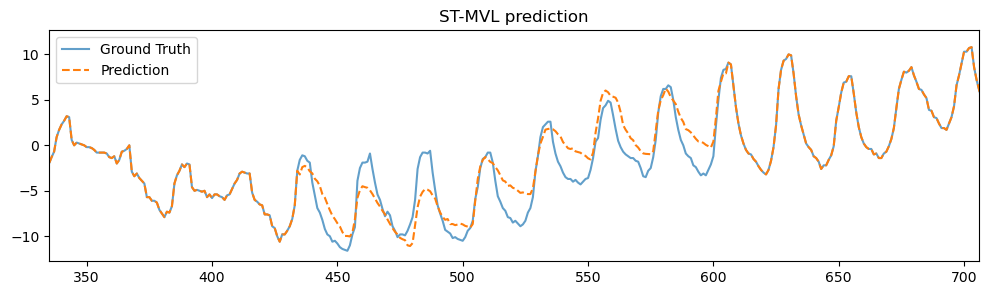

In [11]:
# Play with the parameters
window_size = 12
local_decay = 0.3
temporal_smoothing = 0.3
temporal_threshold = 96

# Split into historical and current data
ts_historical = X_incomplete[:minimum_history, :]
ts_not_historical = X_incomplete[minimum_history:, :]

prediction_stmvl = ST_MVL(
    window_size=window_size, 
    decay_rate=local_decay, 
    smoothing_rate=temporal_smoothing,
    temporal_threshold=temporal_threshold
).fit_transform(ts_historical, ts_not_historical, locations)

plt.figure(figsize=(12, 3))
plt.title("ST-MVL prediction")
plt.plot(ts_data_raw[minimum_history:, 0], alpha=0.7, label="Ground Truth")
plt.plot(prediction_stmvl[:, 0], label="Prediction", linestyle="--")
plt.xlim((hole_start-minimum_history-100, hole_end-minimum_history+100))
plt.legend()
plt.show()

## 4. TKCM

Top-k case matching (TKCM) is a **streaming** algorithm, which means it can be used in an online fashion. Missing data points are immediately recovered from the historical context.

For a time series with missing values, a set of reference time series is used. It assumes that **patterns** in the data can be found at different points.

Specifically, TKCM looks at the sequence of data immediately **preceding** the missing value in all reference sensors. It then searches the historical data for instances where the sensors behaved in the exact same way dynamically. <br> If the temperature dropped by 5ºC in the reference sensors over two hours right before the target sensor broke, TKCM finds the top-$k$ times in history that a similar 5ºC drop occurred in the references, and looks at what the temperature was immediately after in the target sensor.

TKCM follows a three-step process to impute a missing value:
1. **Extract** all EDs between patterns within the reference sensors
2. **Select** the best matching patterns dynamically
3. **Impute** values from patterns by averaging over $k$ reference points

The pseudocode contains a triple-nested loop to find the pattern dissimilarites over the time series, the reference time series and the pattern length. The python runtime loop slows this computation down dramatically. Thus, we split the calculation in its terms and calculate each using numpy's fast vectorization. <br> A neat trick using an additional dimension allows numpy to efficiently handle the distance calculation of the query pattern to all other candidate patterns in a process called broadcasting.

In [12]:
def tkcm(ts_buffer, reference_ts_buffer, offset, window_size, pattern_length, k):
    # 1: Initializations
    n_patterns = window_size - 2 * pattern_length + 1 # L - 2*l + 1 from the paper
    pattern_dissimilarities = np.zeros(n_patterns)

    dynamic_results = np.full((k + 1, n_patterns + 1), np.inf)
    k_anchor_points = np.zeros(k, dtype=int)

    # 2: Calculate ED between query pattern and each historical candidate
    # 2.1: Create index arrays for the query and the historical candidates
    x_indices = np.arange(pattern_length)
    j_indices = np.arange(n_patterns)[:, np.newaxis] # Column vector to trigger broadcasting

    query_idx = (offset - x_indices) % window_size
    candidates_idx = (offset + pattern_length + j_indices - x_indices) % window_size

    # 2.2: Extract values using advanced indexing
    query_patterns = reference_ts_buffer[:, query_idx][:, np.newaxis, :]
    candidates_patterns = reference_ts_buffer[:, candidates_idx]

    # 2.3: Calculate ED across all sensors and patterns simultaneously
    squared_diffs = (candidates_patterns - query_patterns) ** 2
    pattern_dissimilarities = np.sqrt(np.sum(squared_diffs, axis=(0, 2)))

    # 3: Calculate optimal distances for patterns over time
    for j in range(n_patterns + 1):
        dynamic_results[0, j] = 0

        for i in range(1, k+1):
            if i > j:
                dynamic_results[i, j] = np.inf
            else:
                # 3.1: Minimize cost: Either skip pattern or select it and jump back in time
                dynamic_results[i, j] = min(
                    dynamic_results[i, j - 1],
                    pattern_dissimilarities[j-1] + dynamic_results[i - 1, max(j - pattern_length, 0)]
                )

    # 4: Backtracking
    i = k
    j = n_patterns # Start from the very end of the computed patterns

    while i > 0 and j > 0:
        # 4.1: If the cost didn't change, the pattern was skipped - otherwise record its position
        if dynamic_results[i, j] == dynamic_results[i, j - 1]:
            j -= 1

        else:
            k_anchor_points[i - 1] = j
            i -= 1
            j = max(j - pattern_length, 0)

    # 5: Value Imputation
    valid_mask = k_anchor_points > 0

    if not np.any(valid_mask):
        ts_buffer[offset] = np.nan
    else:
        # Calculate their exact indices in the ring buffer
        valid_anchors = k_anchor_points[valid_mask]
        imputation_indices = (offset + pattern_length + valid_anchors - 1) % window_size
        
        # Take the mean of those historical points
        ts_buffer[offset] = np.mean(ts_buffer[imputation_indices])
        
    return ts_buffer[offset]

Because TKCM is meant to be a streaming algorithm, we will feed the data to the algorithm iteratively. It takes buffers of data which are simulated here from our static data.

The missing values are then imputed immediately from the historical context. They are also fed back into the algorithm for future imputations.

In [13]:
n_time_points, n_time_series = X_incomplete.shape

# TKCM parameters
window_size = n_time_points
offset = 0
pattern_length = 72
k = 4

# Streaming objects
ts_buffer = np.zeros(window_size)
reference_ts_buffer = np.zeros((n_time_series - 1, window_size))
prediction_tkcm = np.empty_like(X_incomplete[:, 0])

# Simulate stream
for i in range(n_time_points):
    # Update buffers
    ts_buffer[offset] = X_incomplete[i, 0]
    reference_ts_buffer[:, offset] = X_incomplete[i, 1:]
    
    # Only impute when necessary
    if np.isnan(ts_buffer[offset]):
        pred_value = tkcm(ts_buffer, reference_ts_buffer, offset, window_size, pattern_length, k)

    # Store prediction
    prediction_tkcm[i] = ts_buffer[offset]
    offset = (offset + 1) % window_size

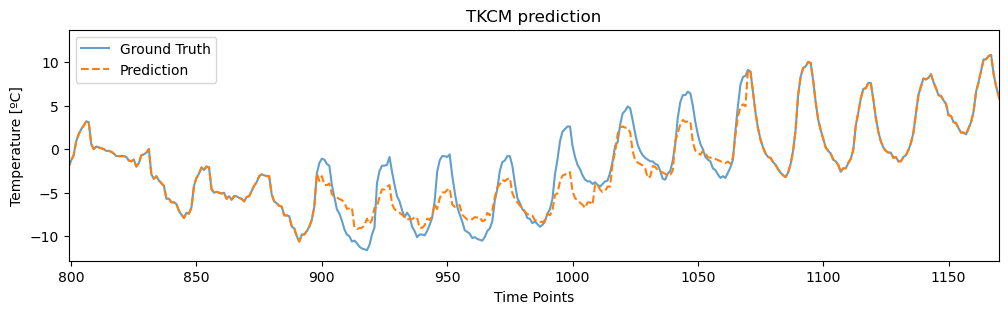

In [14]:
plt.figure(figsize=(12, 3))
plt.title("TKCM prediction")
plt.plot(ts_data_raw[:, 0], alpha=0.7, label="Ground Truth")
plt.plot(prediction_tkcm, label="Prediction", linestyle="--")
plt.xlim((hole_start-100, hole_end+100))
plt.xlabel("Time Points")
plt.ylabel("Temperature [ºC]")
plt.legend()
plt.show()

## 5. Exercises

Take one time series modeling method, e.g. DFT. Try to impute the missing values by extracting dominant features from clean data. This can be done via dimensionality reduction. 

Extrapolate the time series over the missing data block.

In [15]:
from scipy.fft import rfft, irfft

missing_indices = np.where(np.isnan(X_incomplete[:, target_sensor]))[0]
first_nan = missing_indices[0]
fft_historic = ts_data_raw[:first_nan, target_sensor]

# YOUR CODE HERE


Find some unusual patterns in the data and artificially make them missing data. You can plot the data and manually inspect some irregularities. Set the respective windows to `np.nan`values.

Run the different prediction algorithms - do they perform worse?

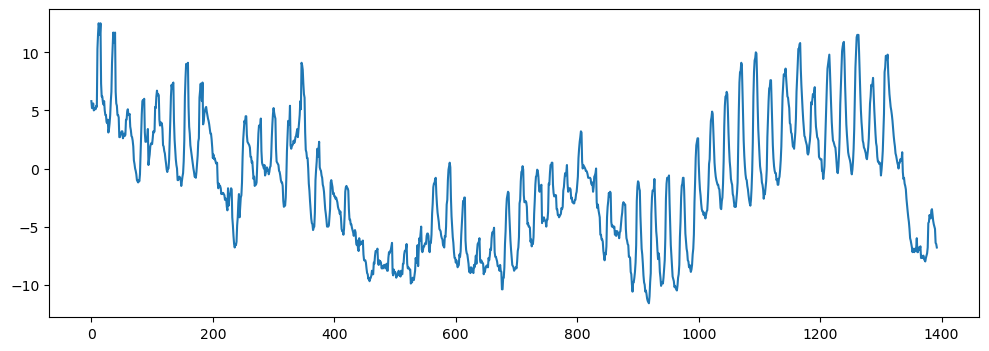

In [16]:
inspecting_sensor = 0

plt.figure(figsize=(12, 4))
plt.plot(ts_data_raw[:, inspecting_sensor])
plt.show()

In [17]:
# YOUR CODE HERE


Vary the size of the missing data block from almost point-based to more than half of the whole time series data. How well do the algorithms perform?

In [18]:
n_missing_data = [1, 10, 100, ts_data_raw.shape[0] // 2]

for block_size in n_missing_data:
    X_incomplete = ts_data_raw.copy()

    hole_end = hole_start + block_size
    X_incomplete[hole_start:hole_end, target_sensor] = np.nan

    # YOUR CODE HERE
    

Use an error metric to formalize the visual differences. Popular error metrics are MAE and MSE. You could also calculate the euclidean distance of your predicted subsequence to the ground truth.

Which of the algorithms really performs the best?

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_true = ts_data_raw[hole_start:hole_end, target_sensor]

# YOUR CODE HERE
# Predictions
y_pred_linear = None
y_pred_cdrec = None
y_pred_stmvl = None
y_pred_tkcm = None

# Errors
